# Sentiment Analysis of IMDB Movie Reviews

<img src='https://www.canakkaleolay.com/public/photos/news/2024/202401/haber-57740/05593667_57740_imdb-siralamasina-gore-en.jpg'>

Bu çalışmanın amacı, IMDb film incelemeleri veri seti kullanılarak doğal dil işleme (NLP) teknikleri ile metin verilerinden duygu (sentiment) çıkarımı gerçekleştirmektir. Kullanıcılar tarafından yazılan yorumların olumlu veya olumsuz olarak sınıflandırılması hedeflenmiştir.

This study aims to perform sentiment analysis on textual data using Natural Language Processing (NLP) techniques based on the IMDb movie reviews dataset. It is intended to classify user-written reviews as either positive or negative.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

from collections import Counter
import neattext.functions as nfx
from nltk.corpus import stopwords

C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df = pd.read_csv('IMDB Dataset.csv')

### EDA

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

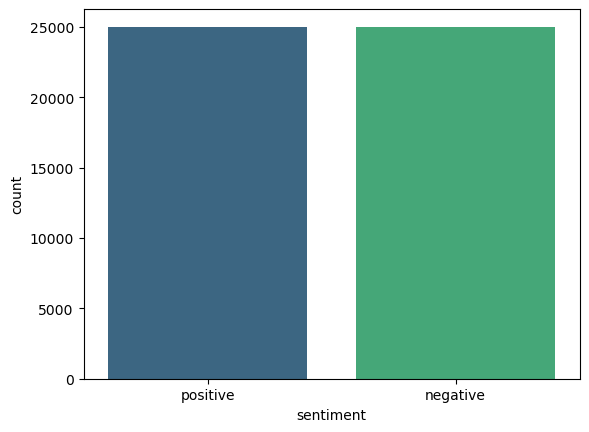

In [6]:
sns.countplot(x=df['sentiment'], hue=df['sentiment'], palette='viridis');

In [7]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [8]:
df['sentiment'].value_counts()

sentiment
1    25000
0    25000
Name: count, dtype: int64

In [9]:
from langdetect import detect
df["language"] = df["review"].apply(detect)

In [10]:
df["language"].value_counts()

language
en    49999
id        1
Name: count, dtype: int64

In [11]:
df = df[df["language"] == 'en']

In [12]:
df['review']=df['review'].str.lower() # küçük harfe çeviriyor
df['review']=df['review'].str.replace('[^\w\s]','', regex=True) # noktolama işaretlerini kaldırır
df['review']=df['review'].str.replace('\d+','', regex=True) # rakamları kaldırır
df['review']=df['review'].str.replace('\n','', regex=True) # satır sonlarını kaldırır
df['review']=df['review'].str.replace('\r','', regex=True) # enter'ları kaldırıyor

In [13]:
df['review'][0]

'one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they are right as this is exactly what happened with mebr br the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordbr br it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awaybr br i would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare for

In [14]:
x = df['review']
y = df[['sentiment']]

In [15]:
x.head()

0    one of the other reviewers has mentioned that ...
1    a wonderful little production br br the filmin...
2    i thought this was a wonderful way to spend ti...
3    basically theres a family where a little boy j...
4    petter matteis love in the time of money is a ...
Name: review, dtype: object

In [16]:
y.head()

,sentiment
0,1
1,1
2,1
3,0
4,1


In [17]:
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords

# NLTK durak kelimeleri indir
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
#tokenizasyon ve kök bulma (lematizasyon) 

In [19]:
def ekkok(text):
    words = TextBlob(text).words
    return [word.lemmatize() for word in words if word.lower() not in stop_words]

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

In [21]:
vect=CountVectorizer()

In [22]:
#vect = CountVectorizer(ngram_range=(1, 2),analyzer=ekkok,stop_words='english')

In [23]:
vect = CountVectorizer(ngram_range=(1, 2),max_features=20000, min_df=5, analyzer=ekkok, stop_words='english' )

In [24]:
x_vect = vect.fit_transform(x).toarray()

In [25]:
x_vect

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(49999, 20000))

In [59]:
x_vect.shape

(49999, 20000)

In [60]:
x_train,x_test,y_train,y_test=train_test_split(x_vect,y,test_size=.2,random_state=42)

In [61]:
tf = pd.DataFrame(vect.transform(x).toarray(), columns=vect.get_feature_names_out())

In [62]:
tf

,aa,aag,aaliyah,aamir,aardman,aaron,ab,aback,abandon,abandoned,...,zoom,zooming,zorro,zu,zucco,zucker,zulu,zuniga,½,à
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49994,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [63]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(x_vect.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  
    metrics=['accuracy']
)

In [64]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [65]:
model.fit(x_train, y_train, batch_size=32, validation_data=(x_test, y_test), epochs=15, verbose=2, callbacks=[early_stop])

Epoch 1/15
1250/1250 - 53s - 42ms/step - accuracy: 0.8660 - loss: 0.3248 - val_accuracy: 0.8995 - val_loss: 0.2525
Epoch 2/15
1250/1250 - 37s - 30ms/step - accuracy: 0.9291 - loss: 0.1857 - val_accuracy: 0.8953 - val_loss: 0.2657
Epoch 3/15
1250/1250 - 37s - 29ms/step - accuracy: 0.9601 - loss: 0.1133 - val_accuracy: 0.8929 - val_loss: 0.3067
Epoch 4/15
1250/1250 - 33s - 26ms/step - accuracy: 0.9771 - loss: 0.0651 - val_accuracy: 0.8924 - val_loss: 0.3799
Epoch 5/15
1250/1250 - 32s - 26ms/step - accuracy: 0.9844 - loss: 0.0470 - val_accuracy: 0.8891 - val_loss: 0.4495
Epoch 6/15
1250/1250 - 32s - 25ms/step - accuracy: 0.9874 - loss: 0.0356 - val_accuracy: 0.8928 - val_loss: 0.5209
Epoch 7/15
1250/1250 - 32s - 26ms/step - accuracy: 0.9894 - loss: 0.0315 - val_accuracy: 0.8935 - val_loss: 0.5124
Epoch 8/15
1250/1250 - 32s - 26ms/step - accuracy: 0.9906 - loss: 0.0292 - val_accuracy: 0.8913 - val_loss: 0.4972
Epoch 9/15
1250/1250 - 44s - 35ms/step - accuracy: 0.9913 - loss: 0.0271 - val_a

In [66]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8995 - loss: 0.2525


[0.25249701738357544, 0.8995000123977661]

In [83]:
neg = df[df['sentiment']==0]['review'].iloc[10]
pos= df[df['sentiment']==1]['review'].iloc[10]

In [84]:
neg

'i had the terrible misfortune of having to view this bmovie in its entiretybr br all i have to say is save your time and money this has got to be the worst bmovie of all time it shouldnt even be called a bmovie more like an fmovie because it fails in all aspects that make a good movie the story is not interesting at all all of the actors are paperthin and not at all believable it has bad direction and the action sequences are so fake its almost funnyalmostbr br the movie is just packed full of crappy oneliners that no respectable person could find amusing in the least little bitbr br this movie is supposed to be geared towards men but all the women in it are so utterly unattractive especially that old wrinkled thing that comes in towards the end they try to appear sexy in those weird horrible costumes and they fail miserablybr br even some of the most ridiculous bmovies will still give you some laughs but this is just too painful to watch'

In [85]:
pos

'after the success of die hard and its sequels its no surprise really that in the s a glut of die hard on a  movies cashed in on the wrong guy wrong place wrong time concept that is what they did with cliffhanger die hard on a mountain just in time to rescue sly stop or my mom will shoot stallones careerbr br cliffhanger is one big nitpickers dream especially to those who are expert at mountain climbing basejumping aviation facial expressions acting skills all in all its full of excuses to dismiss the film as one overblown pile of junk stallone even managed to get outacted by a horse however if you an forget all the nonsense its actually a very lovable and undeniably entertaining romp that delivers as plenty of thrills and unintentionally plenty of laughsbr br youve got to love john lithgows sneery evilness his tick every box band of baddies and best of all the permanently harassed and hapless turncoat agent rex linn as traversbr br he may of been henry in portrait of a serial killer b

In [86]:
text1=vect.transform([neg]).toarray()
p1 = model.predict(text1)
label1 = (p1 > 0.5).astype(int).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


In [87]:
label1

array([0])

In [88]:
text2=vect.transform([pos]).toarray()
p2= model.predict(text2)
label2 = (p2 > 0.5).astype(int).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [89]:
label2

array([1])

In [74]:
#Şimdi en çok tekrar eden kelimeleri bulalım
s=' '.join(df['review'])

In [75]:
Counter(s.split())

Counter({'the': 663924,
         'and': 320702,
         'a': 320547,
         'of': 288389,
         'to': 266781,
         'is': 210159,
         'in': 184877,
         'it': 152919,
         'i': 152128,
         'this': 149412,
         'that': 136091,
         'br': 114872,
         'was': 95225,
         'as': 91235,
         'with': 86848,
         'for': 86730,
         'movie': 83521,
         'but': 81780,
         'film': 74457,
         'on': 66670,
         'not': 59869,
         'you': 59564,
         'are': 58175,
         'his': 57283,
         'have': 55053,
         'be': 52738,
         'he': 51944,
         'one': 51028,
         'its': 49124,
         'at': 46502,
         'all': 45251,
         'by': 44143,
         'an': 42823,
         'they': 41537,
         'from': 40292,
         'who': 40181,
         'so': 39511,
         'like': 38991,
         'or': 34955,
         'just': 34876,
         'her': 34245,
         'about': 33887,
         'if': 33591,
      

In [76]:
#stop wordsleri kaldıracağız şimdi
s2=nfx.remove_stopwords(s)

In [77]:
Counter(s2.split())

Counter({'br': 114872,
         'movie': 83521,
         'film': 74457,
         'like': 38991,
         'good': 28570,
         'time': 23267,
         'story': 22095,
         'great': 17821,
         'bad': 17719,
         'people': 17538,
         'dont': 16951,
         'movies': 15456,
         'films': 15293,
         'way': 15009,
         'characters': 14677,
         'think': 14215,
         'watch': 13569,
         'seen': 13092,
         'character': 12922,
         'love': 12569,
         'acting': 12471,
         'plot': 12365,
         'little': 12329,
         'best': 12325,
         'know': 12267,
         'life': 11683,
         'better': 11045,
         'end': 10537,
         'scene': 10528,
         'man': 10295,
         'scenes': 10177,
         'im': 9480,
         'real': 9004,
         'watching': 8993,
         'thing': 8900,
         'doesnt': 8884,
         'didnt': 8808,
         'actors': 8774,
         'years': 8672,
         'actually': 8418,
         'f

In [78]:
negatif = df[df['sentiment'] == 0]
pozitif = df[df['sentiment'] == 1]

In [79]:
pozitifc=' '.join(pozitif['review'])
pozitifc=nfx.remove_stopwords(pozitifc)

negatifc=' '.join(negatif['review'])
negatifc=nfx.remove_stopwords(negatifc)

In [80]:
pozitif_data = Counter(pozitifc.split()).most_common(20)
pozitif_data = dict(pozitif_data)

negatif_data = Counter(negatifc.split()).most_common(20)
negatif_data = dict(negatif_data)

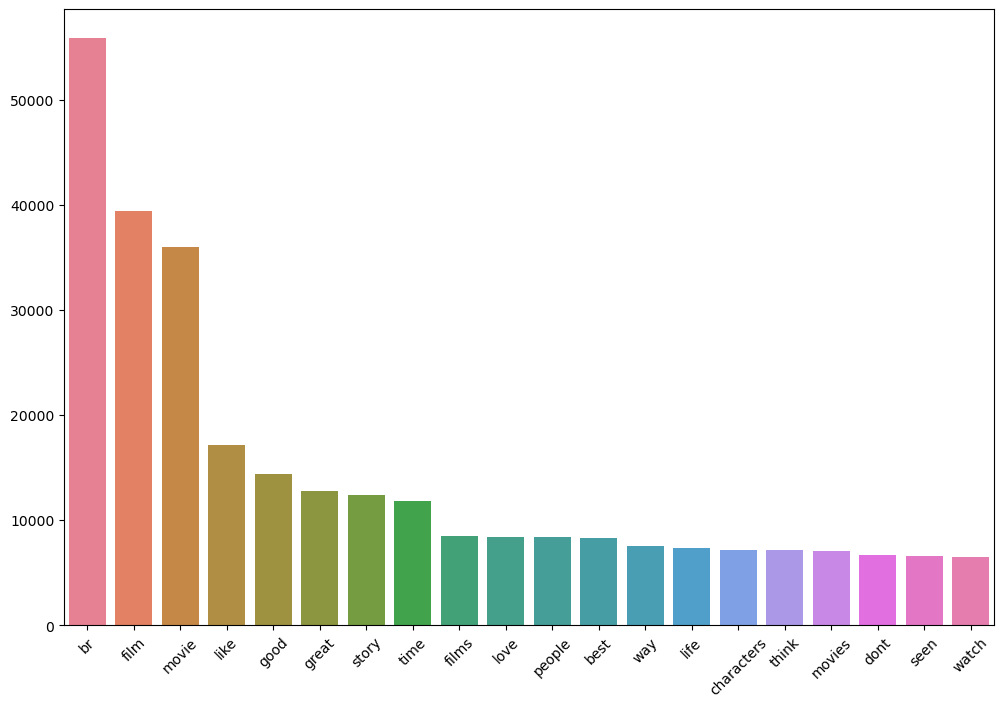

In [81]:
plt.figure(figsize=(12,8))
sns.barplot(x=pozitif_data.keys(), y=pozitif_data.values(), hue=pozitif_data.keys())
plt.xticks(rotation=45);

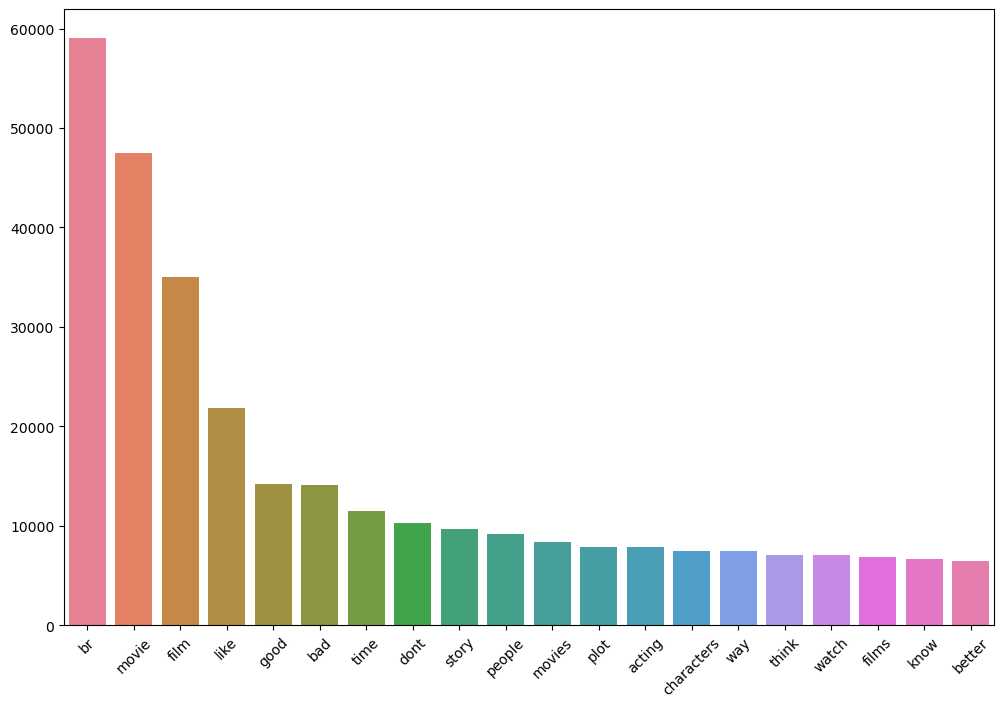

In [82]:
plt.figure(figsize=(12,8))
sns.barplot(x=negatif_data.keys(), y=negatif_data.values(), hue=negatif_data.keys())
plt.xticks(rotation=45);

In [101]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [102]:
def wc(data, color):
    plt.figure(figsize=(10, 10))
    mask=np.array(Image.open('cloud.png'))
    wc = WordCloud(background_color=color, stopwords=STOPWORDS, mask=mask)  
    wc.generate(' '.join(data))
    plt.imshow(wc)
    plt.axis('off')  
    plt.show() 

In [103]:
negatif = df[df['sentiment'] == 0]
pozitif = df[df['sentiment'] == 1]

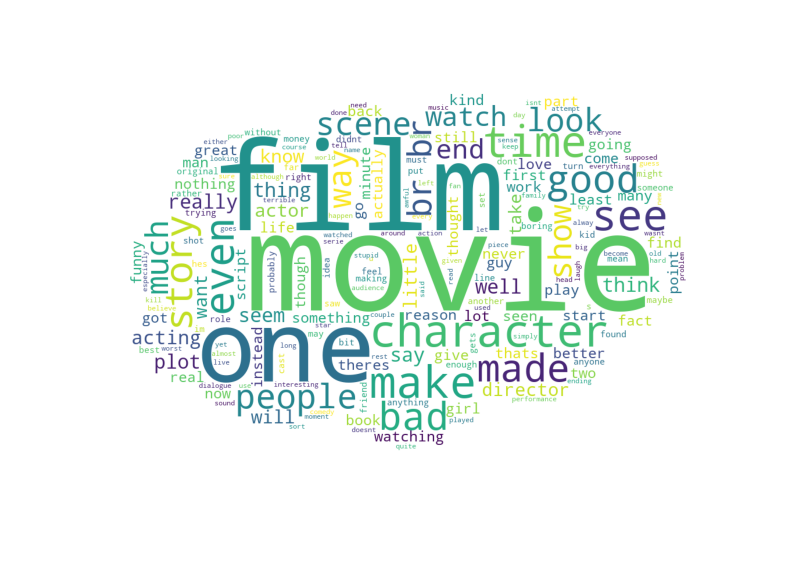

In [106]:
wc(negatif['review'],'white')

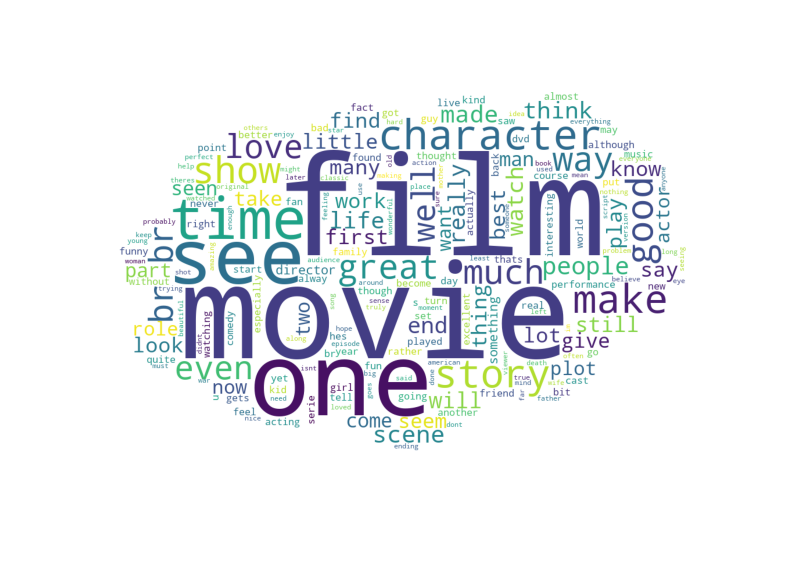

In [108]:
wc(pozitif['review'],'white')

### Sentiment Analysis with machine learning

In [91]:
ybw=df[(df.sentiment==0) | (df.sentiment==1) ]

In [92]:
ybw.reset_index(drop=True, inplace=True)

In [93]:
x=ybw[['review']]
y=ybw[['sentiment']]

In [94]:
x.head()

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production br br the filmin...
2,i thought this was a wonderful way to spend ti...
3,basically theres a family where a little boy j...
4,petter matteis love in the time of money is a ...


In [95]:
y.head()

,sentiment
0,1
1,1
2,1
3,0
4,1


In [96]:
yenix=vect.fit_transform(x['review'])

In [97]:
x_train, x_test, y_train, y_test=train_test_split(yenix,y, random_state=42, test_size=.20)

In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [109]:
algo_test(yenix,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[4361  600]
 [ 801 4238]]
LogisticRegression()  modeli eğitiliyor!..
[[4355  606]
 [ 595 4444]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[3658 1303]
 [1396 3643]]
RandomForestClassifier()  modeli eğitiliyor!..
[[4292  669]
 [ 735 4304]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[3772 1189]
 [ 672 4367]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[3411 1550]
 [2293 2746]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[3363 1598]
 [ 843 4196]]
MultinomialNB()  modeli eğitiliyor!..
[[4332  629]
 [ 791 4248]]
Eğitim tamamlandı.
En başarılı model:  LogisticRegression
Confusion Matrix:
[[4355  606]
 [ 595 4444]]
classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4961
           1       0.88      0.88      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
wei

,Accuracy,Precision,Recall,F1
LogisticRegression,0.8799,0.8799,0.8799,0.8799
BernoulliNB,0.8599,0.8599,0.8599,0.8599
RandomForestClassifier,0.8596,0.8596,0.8596,0.8596
MultinomialNB,0.8580,0.8580,0.8580,0.8580
GradientBoostingClassifier,0.8139,0.8139,0.8139,0.8139
AdaBoostClassifier,0.7559,0.7559,0.7559,0.7559
DecisionTreeClassifier,0.7301,0.7301,0.7301,0.7301
KNeighborsClassifier,0.6157,0.6157,0.6157,0.6157


Makine öğrenmesi algoritmaları ile elde edilen sonuçlara göre en yüksek performans Logistic Regression modeli tarafından sağlanmış ve %87.99 doğruluk accuracy, precision, recall ve F1 skorlarına ulaşılmıştır. Naive Bayes ve Random Forest gibi diğer modeller de benzer şekilde yaklaşık %85–86 bandında performans göstermiştir. 

Derin öğrenme modeli ise %89.95 doğruluk oranı ve 0.2525 loss değeri ile tüm makine öğrenmesi modellerine kıyasla daha yüksek bir performans sergilemiştir.

According to the results obtained from machine learning algorithms, the highest performance was achieved by the Logistic Regression model, reaching 87.99% accuracy, precision, recall, and F1 scores. Other models such as Naive Bayes and Random Forest showed similar performance, achieving approximately 85–86%.

The deep learning model, on the other hand, outperformed all machine learning models with an accuracy of 89.95% and a loss value of 0.2525.

In [112]:
import joblib
import os

# Klasör oluştur
os.makedirs('models', exist_ok=True)

# Modeli kaydet
print("Model kaydediliyor...")
joblib.dump(model, 'models/sentiment_model.pkl')
print("✅ Model kaydedildi: models/sentiment_model.pkl")

# Vectorizer'ı kaydet
print("Vectorizer kaydediliyor...")
joblib.dump(vect, 'models/vectorizer.pkl')
print("✅ Vectorizer kaydedildi: models/vectorizer.pkl")

# Stop words'ü kaydet
print("Stop words kaydediliyor...")
joblib.dump(stop_words, 'models/stopwords.pkl')
print("✅ Stop words kaydedildi: models/stopwords.pkl")

print("\n🎉 Tüm dosyalar başarıyla kaydedildi!")

Model kaydediliyor...
✅ Model kaydedildi: models/sentiment_model.pkl
Vectorizer kaydediliyor...
✅ Vectorizer kaydedildi: models/vectorizer.pkl
Stop words kaydediliyor...
✅ Stop words kaydedildi: models/stopwords.pkl

🎉 Tüm dosyalar başarıyla kaydedildi!
